In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import chain
import geopandas as gpd

In [2]:
df_inicial = pl.read_ods('tabela10301.ods')

In [3]:
df_inicial.head()

"Brasil, Grande Região e Unidade da Federação",2022
str,f64
"""Brasil""",0.542
"""Norte""",0.545
"""Nordeste""",0.541
"""Sudeste""",0.53
"""Sul""",0.476


In [4]:
df_inicial = df_inicial.rename({    
    'Brasil, Grande Região e Unidade da Federação': 'regiao',
    '2022': 'gini'
})

In [5]:
df_inicial.head()

regiao,gini
str,f64
"""Brasil""",0.542
"""Norte""",0.545
"""Nordeste""",0.541
"""Sudeste""",0.53
"""Sul""",0.476


In [6]:
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

In [7]:
df_regioes = (
    df_inicial.filter(
        pl.col('regiao').is_in(regioes)
    )
    .sort('gini', descending=True)
)

In [8]:
df_regioes.head()

regiao,gini
str,f64
"""Norte""",0.545
"""Nordeste""",0.541
"""Centro-Oeste""",0.531
"""Sudeste""",0.53
"""Sul""",0.476


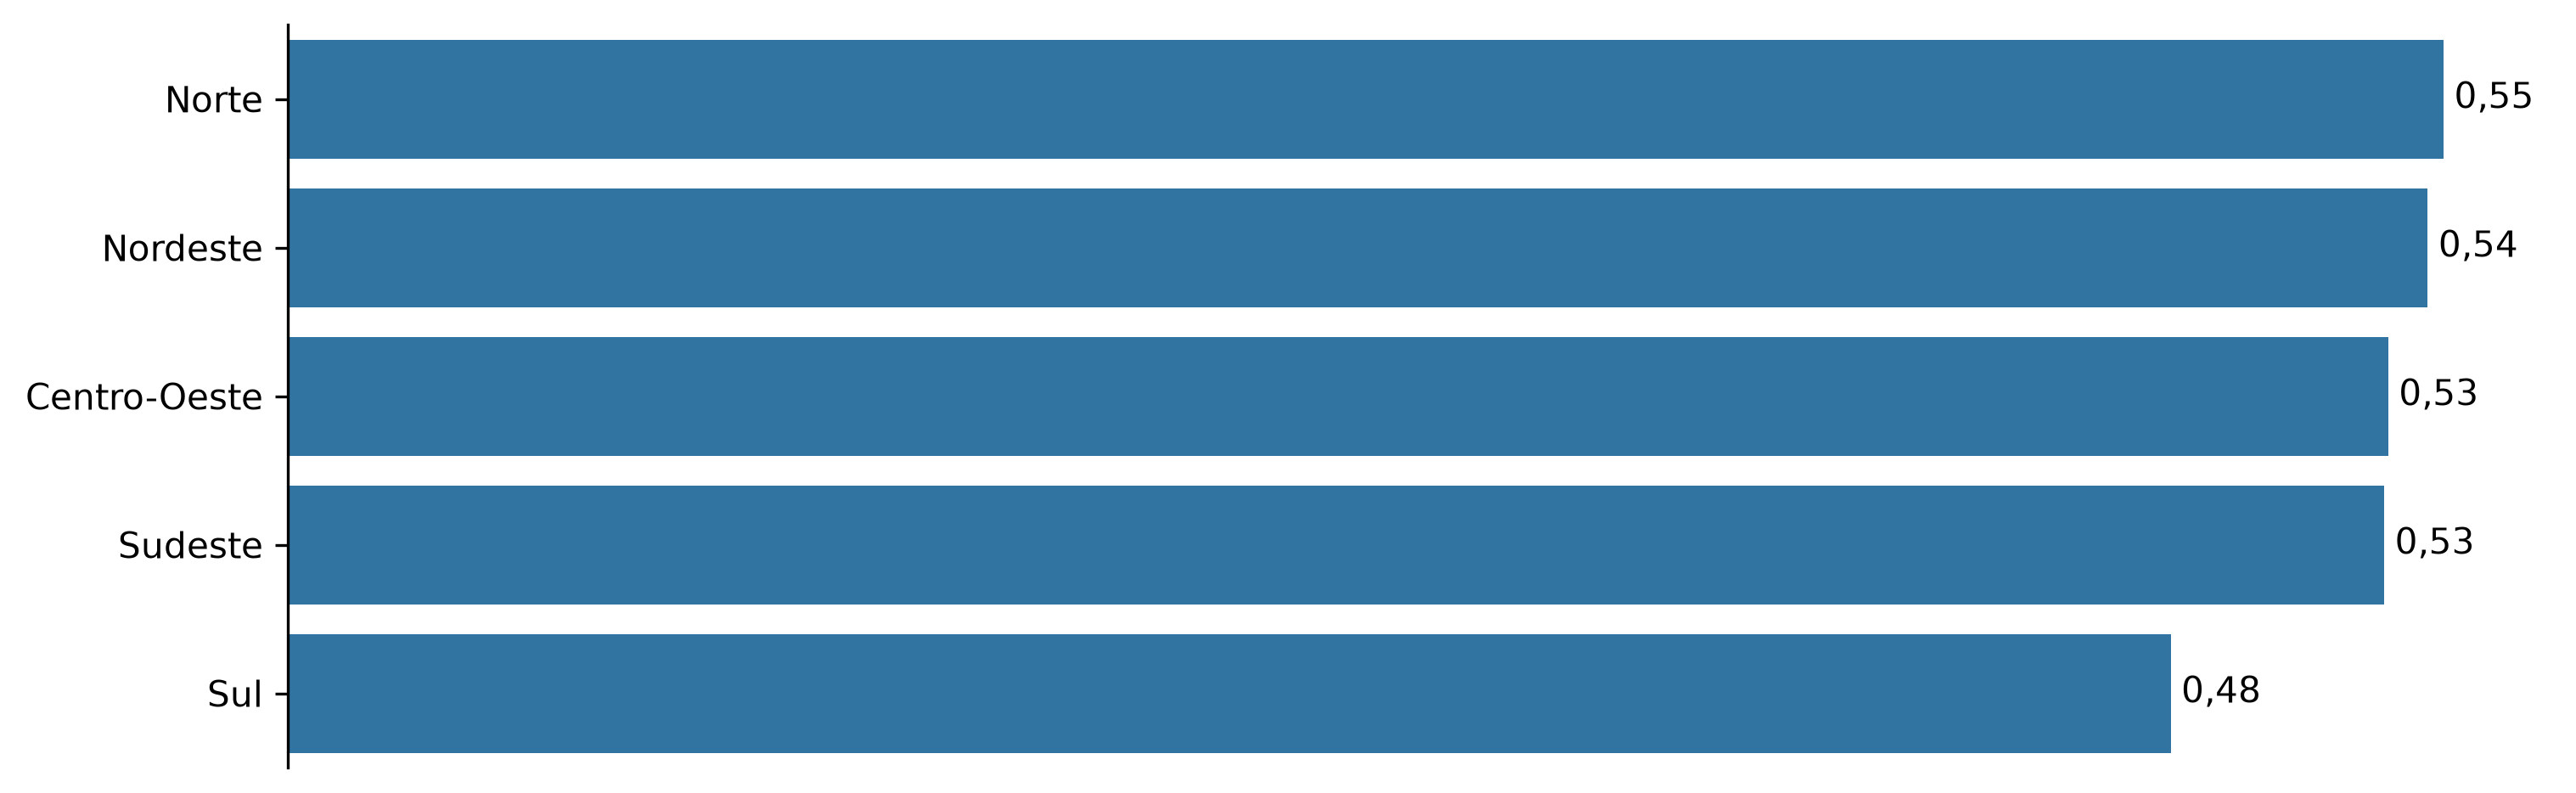

In [9]:
fig, ax = plt.subplots(
    figsize=(10, 3),
    dpi=300,
    layout='constrained'
)

bar = sns.barplot(
    data=df_regioes,
    x='gini',
    y='regiao'
)

ax.bar_label(
    ax.containers[0], 
    fmt=lambda x: f'{x:.2f}'.replace('.', ','), 
    padding=3
)

ax.set_ylabel('')
ax.set_xlabel('')
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.xaxis.set_visible(False)

fig.savefig('tabela10301_regioes', dpi=330, bbox_inches='tight')
plt.show()

In [10]:
nao_ufs = list(chain(regioes, ['Brasil']))
print(nao_ufs)

['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste', 'Brasil']


In [11]:
df_ufs = (
    df_inicial.filter(
        ~pl.col('regiao').is_in(nao_ufs)
    )
    .rename({
        'regiao': 'uf'
    })
)

In [12]:
df_ufs.head()

uf,gini
str,f64
"""Rondônia""",0.489
"""Acre""",0.547
"""Amazonas""",0.572
"""Roraima""",0.572
"""Pará""",0.539


In [13]:
gdf_ufs = gpd.read_file('../../../complementar/BR_UF_2025/')

ERROR 1: PROJ: proj_create_from_database: Open of /home/lazaro/miniforge3/envs/dev/share/proj failed


In [14]:
gdf_ufs.head()

,CD_UF,NM_UF,SIGLA_UF,CD_REGIAO,NM_REGIAO,SIGLA_RG,AREA_KM2,geometry
0,43,Rio Grande do Sul,RS,4,Sul,S,281707.150,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825..."
1,35,São Paulo,SP,3,Sudeste,SE,248219.485,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607..."
2,32,Espírito Santo,ES,3,Sudeste,SE,46074.440,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384..."
3,33,Rio de Janeiro,RJ,3,Sudeste,SE,43750.424,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029..."
4,41,Paraná,PR,4,Sul,S,199293.571,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732..."


In [15]:
gdf_ufs['NM_REGIAO'] = gdf_ufs['NM_REGIAO'].replace({
    'Centro-oeste': 'Centro-Oeste'
})

In [16]:
gdf_ufs['NM_REGIAO'].unique()

<ArrowStringArray>
['Sul', 'Sudeste', 'Nordeste', 'Centro-Oeste', 'Norte']
Length: 5, dtype: str

In [17]:
gdf_ufs_temp = gdf_ufs.merge(
    df_ufs.to_pandas(),
    left_on='NM_UF',
    right_on='uf'
)

In [18]:
gdf_ufs_temp.head()

,CD_UF,NM_UF,SIGLA_UF,CD_REGIAO,NM_REGIAO,SIGLA_RG,AREA_KM2,geometry,uf,gini
0,43,Rio Grande do Sul,RS,4,Sul,S,281707.150,"MULTIPOLYGON (((-53.52154 -33.25881, -53.51825...",Rio Grande do Sul,0.484
1,35,São Paulo,SP,3,Sudeste,SE,248219.485,"MULTIPOLYGON (((-48.03575 -25.35712, -48.03607...",São Paulo,0.525
2,32,Espírito Santo,ES,3,Sudeste,SE,46074.440,"MULTIPOLYGON (((-40.88385 -21.16198, -40.88384...",Espírito Santo,0.505
3,33,Rio de Janeiro,RJ,3,Sudeste,SE,43750.424,"MULTIPOLYGON (((-44.72025 -23.35934, -44.72029...",Rio de Janeiro,0.574
4,41,Paraná,PR,4,Sul,S,199293.571,"MULTIPOLYGON (((-48.40723 -25.84254, -48.40732...",Paraná,0.482


In [19]:
gdf_ufs_temp = (
    gdf_ufs_temp.drop(columns=[
        'CD_UF', 'NM_UF', 'CD_REGIAO', 'SIGLA_RG', 'AREA_KM2'
    ])
    .rename(columns={
        'SIGLA_UF': 'sigla_uf', 
        'NM_REGIAO': 'regiao'
    })
)

In [20]:
type(gdf_ufs_temp)

geopandas.geodataframe.GeoDataFrame

In [21]:
gdf_ufs_temp.columns

Index(['sigla_uf', 'regiao', 'geometry', 'uf', 'gini'], dtype='str')

In [22]:
gdf_ufs_temp.to_file('tabela10301_ufs.gpkg', driver='GPKG')

In [23]:
gdf_ufs_temp.to_file('tabela10301_ufs.geojson', driver='GeoJson')